In [7]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "ARIMA": "../model_outputs/arima_trend_metrics.json",
    "Prophet": "../model_outputs/prophet_metrics.json",
    "SARIMAX": "../model_outputs/sarimax_metrics.json",
    "LSTM": "../model_outputs/lstm_metrics.json"
}

metrics_list = []

for model_name, path in files.items():
    with open(path, "r") as f:
        data = json.load(f)
        metrics_list.append(data)

df_metrics = pd.DataFrame(metrics_list)
df_metrics


,model,aic,rmse,mae,mape
0,"ARIMA(3, 1, 7)+trend",1147.180346,12.576404,10.295488,13.420628
1,Prophet,NaN,11.181025,9.892086,13.645760
2,SARIMAX (untuned),NaN,13.487800,10.986700,14.280000
3,LSTM (tuned),NaN,2.271154,1.796324,2.468642


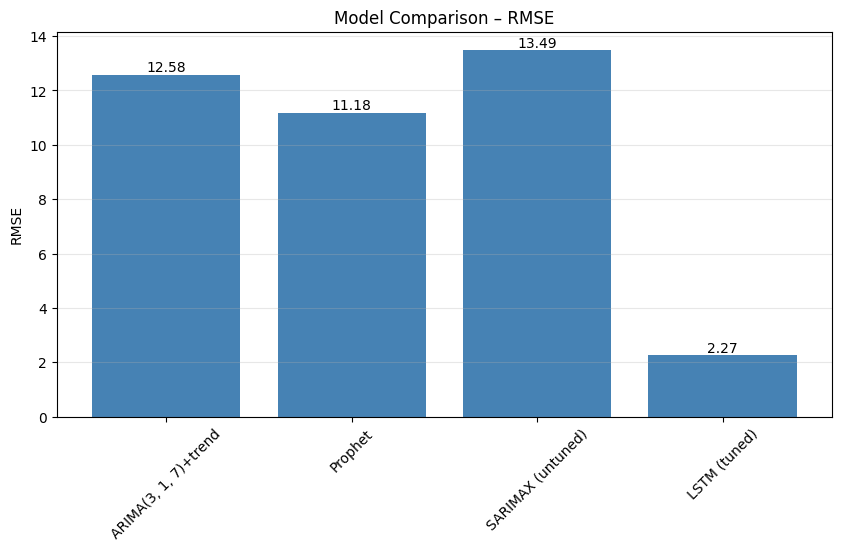

In [12]:
plt.figure(figsize=(10,5))
bars = plt.bar(df_metrics['model'], df_metrics['rmse'], color='steelblue')

plt.title("Model Comparison – RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}", ha='center', va='bottom')

plt.show()


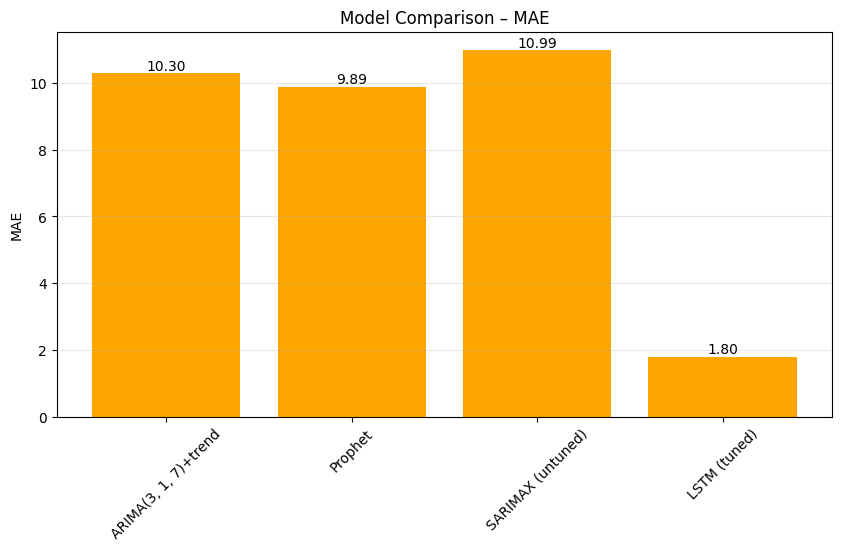

In [13]:
plt.figure(figsize=(10,5))
bars = plt.bar(df_metrics['model'], df_metrics['mae'], color='orange')

plt.title("Model Comparison – MAE")
plt.ylabel("MAE")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}", ha='center', va='bottom')

plt.show()


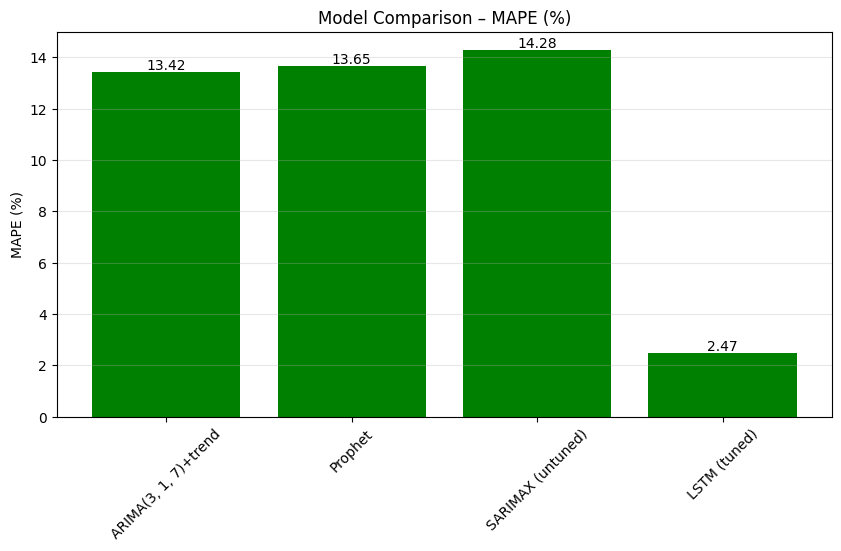

In [14]:
plt.figure(figsize=(10,5))
bars = plt.bar(df_metrics['model'], df_metrics['mape'], color='green')

plt.title("Model Comparison – MAPE (%)")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}", ha='center', va='bottom')

plt.show()


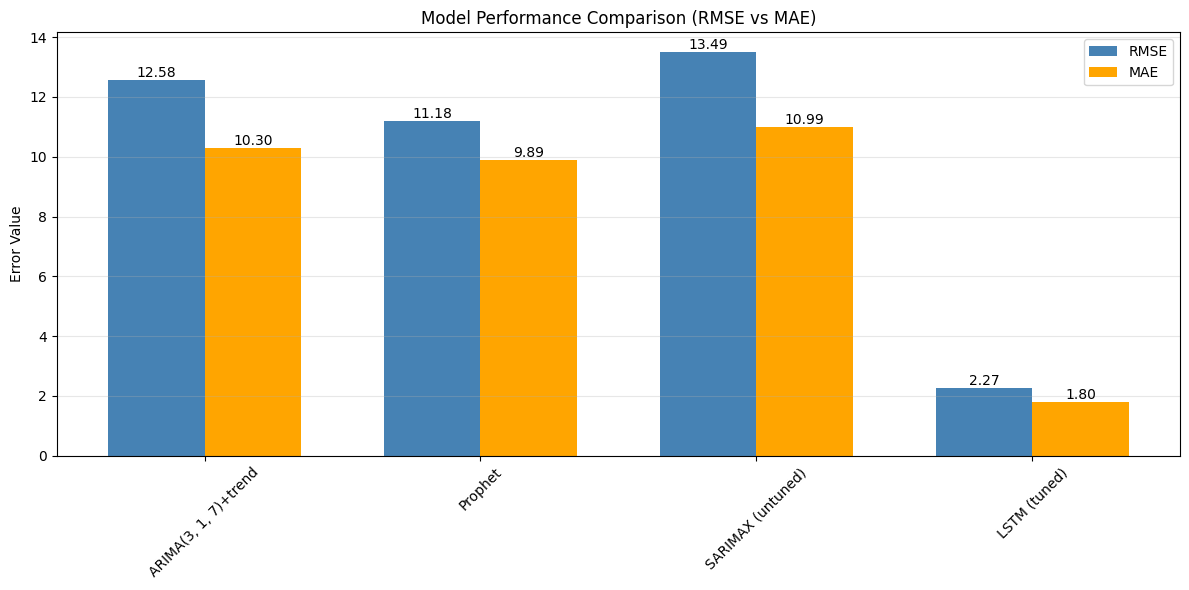

In [15]:
plt.figure(figsize=(12,6))

x = np.arange(len(df_metrics))
width = 0.35

rmse_bars = plt.bar(x - width/2, df_metrics['rmse'], width, label='RMSE', color='steelblue')
mae_bars = plt.bar(x + width/2, df_metrics['mae'], width, label='MAE', color='orange')

plt.xticks(x, df_metrics['model'], rotation=45)
plt.ylabel("Error Value")
plt.title("Model Performance Comparison (RMSE vs MAE)")
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add RMSE labels
for bar in rmse_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}", ha='center', va='bottom')

# Add MAE labels
for bar in mae_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()
